### Programming for Biomedical Informatics
#### Week 9 Assignment - 

In this weekly mini assignment you will use [`pronto`](https://pypi.org/project/pronto/) to find the term name associated with an ontology term id and use it to create a summary data based on data from the GenCC (that we worked with earlier in the course).

The GenCC schema uses CURIEs (compact URIs) which have the form prefix:identifier, for example `HGNC:10896` which is a Human Genome Nomenclature Committee (HGNC) gene identifier. We are going to extract information about the mode of inheritance (MOI) for the diseases in GenCC and use ontologies to add information to our analyses. In this case the MOI accessions are actually terms from the human phenotype ontology (HPO).

- link to the current HPO OBO file download - http://purl.obolibrary.org/obo/hp.obo
- [HPO homepage at BioPortal](https://bioportal.bioontology.org/ontologies/HP)

We did something similar in the snippet this week.

In [2]:
# You may need to install these packages first
# %pip install pronto

# handling www based requests (like APIs)

import urllib as ul

# ontology handling
import pronto
# standard Python data handling modules
import pandas as pd
import numpy as np
# working with nicer tables
import prettytable as PrettyTable

In [3]:
# fetch the Human Phenotype Onology OBO file and parse it with pronto

# download the GO ontology OBO file
import urllib.request

current_hpo_url = 'http://purl.obolibrary.org/obo/hp.obo'

# download the file
urllib.request.urlretrieve(current_hpo_url,'hpo.obo');

# parse the file
go = pronto.Ontology('hpo.obo')

C:\Users\james\AppData\Local\Temp\ipykernel_42088\2948879426.py:12: UnicodeWarning: unsound encoding, assuming ISO-8859-1 (73% confidence)
  go = pronto.Ontology('hpo.obo')


In [4]:
# load the GenCC data
gencc = pd.read_csv('gencc-submissions.tsv', sep='\t')
gencc.head()

,uuid,gene_curie,gene_symbol,disease_curie,disease_title,disease_original_curie,disease_original_title,classification_curie,classification_title,moi_curie,...,submitted_as_submitter_name,submitted_as_classification_id,submitted_as_classification_name,submitted_as_date,submitted_as_public_report_url,submitted_as_notes,submitted_as_pmids,submitted_as_assertion_criteria_url,submitted_as_submission_id,submitted_run_date
0,GENCC_000101-HGNC_10896-OMIM_182212-HP_0000006...,HGNC:10896,SKI,MONDO:0008426,Shprintzen-Goldberg syndrome,OMIM:182212,Shprintzen-Goldberg syndrome,GENCC:100001,Definitive,HP:0000006,...,Ambry Genetics,GENCC:100001,Definitive,2018-03-30 13:31:56,NaN,NaN,NaN,PMID: 28106320,1034,2020-12-24
1,GENCC_000101-HGNC_16636-OMIM_171300-HP_0000006...,HGNC:16636,KIF1B,MONDO:0008233,pheochromocytoma,OMIM:171300,"{Pheochromocytoma, susceptibility to}",GENCC:100003,Moderate,HP:0000006,...,Ambry Genetics,GENCC:100003,Moderate,2019-12-04 13:30:43,NaN,NaN,NaN,PMID: 28106320,69237,2020-12-24
2,GENCC_000101-HGNC_16636-OMIM_118210-HP_0000006...,HGNC:16636,KIF1B,MONDO:0007308,Charcot-Marie-Tooth disease type 2A1,OMIM:118210,"Charcot-Marie-Tooth disease, type 2A1",GENCC:100004,Limited,HP:0000006,...,Ambry Genetics,GENCC:100004,Limited,2022-09-02 00:00:00,NaN,NaN,NaN,https://onlinelibrary.wiley.com/doi/10.1002/hu...,61327,2023-08-19
3,GENCC_000101-HGNC_17939-OMIM_617532-HP_0000007...,HGNC:17939,SLC45A1,MONDO:0044322,intellectual developmental disorder with neuro...,OMIM:617532,Intellectual developmental disorder with neuro...,GENCC:100004,Limited,HP:0000007,...,Ambry Genetics,GENCC:100004,Limited,2020-06-26 13:32:00,NaN,NaN,NaN,PMID: 28106320,72178,2020-12-24
4,GENCC_000101-HGNC_11071-OMIM_616291-HP_0000007...,HGNC:11071,SLC9A1,MONDO:0014572,Lichtenstein-Knorr syndrome,OMIM:616291,Lichtenstein-Knorr syndrome,GENCC:100004,Limited,HP:0000007,...,Ambry Genetics,GENCC:100004,Limited,2018-08-31 13:32:02,NaN,NaN,NaN,PMID: 28106320,1705,2020-12-24


In [5]:
# find the unique MOI CURIEs
moi_curies = gencc['moi_curie'].unique()

# use pronto to find the MOI terms
moi_terms = [go[m] for m in moi_curies]

In [6]:
# print the terms using PrettyTable with the ID and name
t = PrettyTable.PrettyTable(['ID','Name'])
for term in moi_terms:
    t.add_row([term.id,term.name])
print(t) # split between receissive and

+------------+---------------------------------------------------------+
|     ID     |                           Name                          |
+------------+---------------------------------------------------------+
| HP:0000006 |              Autosomal dominant inheritance             |
| HP:0000007 |             Autosomal recessive inheritance             |
| HP:0001417 |                   X-linked inheritance                  |
| HP:0000005 |                   Mode of inheritance                   |
| HP:0001450 |                   Y-linked inheritance                  |
| HP:0001419 |              X-linked recessive inheritance             |
| HP:0001423 |              X-linked dominant inheritance              |
| HP:0012275 | Autosomal dominant inheritance with maternal imprinting |
| HP:0001442 |              Typified by somatic mosaicism              |
| HP:0001427 |                Mitochondrial inheritance                |
| HP:0012274 | Autosomal dominant inheritance with 

In [7]:
# we now want to create a table with a count of the number of entries associated with each MOI term
# create a table where the columns are 'Mode of Inheritance Name', 'TermID', and 'Number of Entries'
moi_count = pd.DataFrame(columns=['Mode of Inheritance Name', 'TermID', 'Number of Entries'])

# loop over the MOI terms
for term in moi_terms:
    # get the number of entries associated with the term
    n_entries = len(gencc[gencc['moi_curie'] == term.id])
    # add a row to the table using concat
    moi_count = pd.concat([moi_count, pd.DataFrame([[term.name, term.id, n_entries]], columns=['Mode of Inheritance Name', 'TermID', 'Number of Entries'])])

# sort the table by the number of entries in descending order
moi_count = moi_count.sort_values(by='Number of Entries', ascending=False)

# print the table using PrettyTable
t = PrettyTable.PrettyTable(['Mode of Inheritance Name', 'TermID', 'Number of Entries'])

for index, row in moi_count.iterrows():
    t.add_row([row['Mode of Inheritance Name'], row['TermID'], row['Number of Entries']])
print(t)

+---------------------------------------------------------+------------+-------------------+
|                 Mode of Inheritance Name                |   TermID   | Number of Entries |
+---------------------------------------------------------+------------+-------------------+
|             Autosomal recessive inheritance             | HP:0000007 |        9122       |
|              Autosomal dominant inheritance             | HP:0000006 |        7677       |
|                   X-linked inheritance                  | HP:0001417 |        952        |
|                   Mode of inheritance                   | HP:0000005 |        329        |
|              X-linked recessive inheritance             | HP:0001419 |        144        |
|                 Semidominant inheritance                | HP:0032113 |        133        |
|                Mitochondrial inheritance                | HP:0001427 |        100        |
|              X-linked dominant inheritance              | HP:0001423

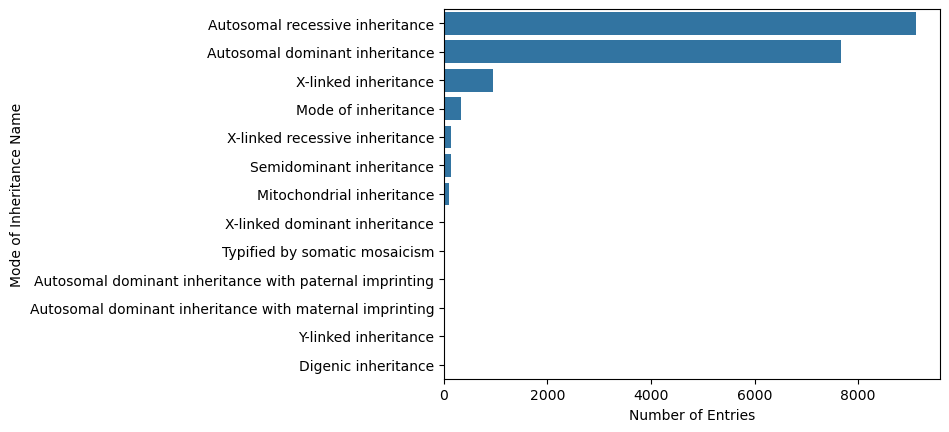

In [8]:
# plot the table as a barplot using seaborn
import seaborn as sns
sns.barplot(x='Number of Entries', y='Mode of Inheritance Name', data=moi_count);